# End-to-end Learning with Autoencoders — Rayleigh / Pilot-CSI / CNN

Reordered by dependency: **all definitions first (Sections 1-6), all execution after (from Section 7)**. Run All works end-to-end.

This week: block-fading + pilot-estimated CSI → diagnose and fix the U-shaped BER → meet the 1e-2 target → sweep P for the optimum → CNN comparison.

## 1. Imports and parameters

In [2]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import pickle

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch._dynamo

from sionna.phy import Block
from sionna.phy.channel import AWGN
from sionna.phy.utils import ebnodb2no, expand_to_rank, sim_ber
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.mapping import Mapper, Demapper, Constellation, BinarySource

sionna.phy.config.seed = 42  # Set seed for reproducible random number generation

%matplotlib inline

In [3]:
###############################################
# SNR range for evaluation and training [dB]
###############################################
ebno_db_min = 4.0
ebno_db_max = 8.0

###############################################
# Modulation and coding configuration
###############################################
num_bits_per_symbol = 6  # Baseline is 64-QAM
modulation_order = 2**num_bits_per_symbol
coderate = 0.5  # Coderate for the outer code
n = 1500  # Codeword length [bit]. Must be a multiple of num_bits_per_symbol
num_symbols_per_codeword = n // num_bits_per_symbol  # Number of modulated baseband symbols per codeword
k = int(n * coderate)  # Number of information bits per codeword

###############################################
# Training configuration
###############################################
num_training_iterations_conventional = 10000  # Number of training iterations for conventional training
# Number of training iterations with RL-based training for the alternating training phase and fine-tuning of the receiver phase
num_training_iterations_rl_alt = 7000
num_training_iterations_rl_finetuning = 3000
training_batch_size = 128  # Training batch size
rl_perturbation_var = 0.01  # Variance of the perturbation used for RL-based training of the transmitter
model_weights_path_conventional_training = "awgn_autoencoder_weights_conventional_training"  # Filename to save the autoencoder weights once conventional training is done
model_weights_path_rl_training = "awgn_autoencoder_weights_rl_training"  # Filename to save the autoencoder weights once RL-based training is done

###############################################
# Evaluation configuration
###############################################
results_filename = "awgn_autoencoder_results"  # Location to save the results

## 2. Networks and end-to-end system classes (MLP demapper)

In [4]:
class NeuralDemapper(nn.Module):
    """Neural network-based demapper with three dense layers and ReLU activation.

    width: hidden layer size (default 128, the tutorial's original value).
    """

    def __init__(self, width=128):
        super().__init__()
        self._dense_1 = nn.Linear(3, width)
        self._dense_2 = nn.Linear(width, width)
        self._dense_3 = nn.Linear(width, num_bits_per_symbol)  # Output LLRs for every bit

    def forward(self, y, no):
        # Using log10 scale helps with the performance
        no_db = torch.log10(no)

        # AWGN passes no as [batch size, 1] and needs broadcasting.
        # Rayleigh passes a per-symbol no_eff that is already [batch size, num_symbols_per_codeword].
        if no_db.shape[1] == 1:
            no_db = no_db.expand(-1, num_symbols_per_codeword)

        z = torch.stack([y.real, y.imag, no_db], dim=2)

        llr = F.relu(self._dense_1(z))
        llr = F.relu(self._dense_2(llr))
        llr = self._dense_3(llr)

        return llr

In [5]:
class E2ESystemConventionalTraining(nn.Module):
    """End-to-end communication system for conventional training.
    
    This system transmits bits modulated using a trainable constellation over
    an AWGN channel. The receiver uses a neural network-based demapper.
    """

    def __init__(self, training):
        super().__init__()
        
        self._training = training
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            # num_bits_per_symbol is required for the interleaver
            self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        
        # Trainable constellation
        # We initialize a custom constellation with QAM points
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.points_r = nn.Parameter(qam_points.real.clone())
        self.points_i = nn.Parameter(qam_points.imag.clone())

        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=torch.complex(self.points_r, self.points_i),
                                           normalize=True,
                                           center=True)
       
        
        self._mapper = Mapper(constellation=self.constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        # We use the previously defined neural network for demapping
        self._demapper = NeuralDemapper()
        # To reduce the computational complexity of training, the outer code is not used when training
        if not self._training:
            self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        
        # Update constellation points from trainable parameters (creates fresh graph)
        self.constellation.points = torch.complex(self.points_r, self.points_i)

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        # Outer coding is only performed if not training
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        # Modulation
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x, no)  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        llr = llr.reshape(batch_size, n)
        # If training, outer decoding is not performed and the BCE is returned
        if self._training:
            loss = F.binary_cross_entropy_with_logits(llr, c)
            return loss
        else:
            # Outer decoding
            b_hat = self._decoder(llr)
            return b, b_hat  # Ground truth and reconstructed information bits returned for BER/BLER computation

In [6]:
class E2ESystemRayleigh(E2ESystemConventionalTraining):
    """Same TX/RX, but over i.i.d. Rayleigh flat fading with perfect CSI."""

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)

        # Transmitter
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        x = self._mapper(c)

        # Channel: Rayleigh flat fading
        std = 0.5 ** 0.5
        h_r = torch.randn(x.shape, device=x.device, dtype=x.real.dtype) * std
        h_i = torch.randn(x.shape, device=x.device, dtype=x.real.dtype) * std
        h = torch.complex(h_r, h_i)
        y = self._channel(h * x, no)

        # Receiver: coherent equalization
        z = y / h
        no_eff = no / (h.real ** 2 + h.imag ** 2)

        llr = self._demapper(z, no_eff)
        llr = llr.reshape(batch_size, n)

        if self._training:
            loss = F.binary_cross_entropy_with_logits(llr, c)
            return loss
        else:
            b_hat = self._decoder(llr)
            return b, b_hat

## 3. Utility functions (train / save / load weights)

In [7]:
def conventional_training(model):
    """Train the model using conventional SGD with backpropagation."""
    # Optimizer used to apply gradients
    optimizer = torch.optim.Adam(model.parameters())
    device = sionna.phy.config.device
    
    for i in range(num_training_iterations_conventional):
        optimizer.zero_grad()
        # Sampling a batch of SNRs
        ebno_db = torch.empty(training_batch_size, device=device).uniform_(ebno_db_min, ebno_db_max)
        # Forward pass
        loss = model(training_batch_size, ebno_db)
        # Computing and applying gradients
        loss.backward()
        optimizer.step()
        # Printing periodically the progress
        if i % 100 == 0:
            print(f'Iteration {i}/{num_training_iterations_conventional}  BCE: {loss.item():.4f}', end='\r')
    print()
    model.eval()
    optimizer.zero_grad(set_to_none=True)

In [8]:
def save_weights(model, model_weights_path):
    m = getattr(model, "_orig_mod", model)
    torch.save(m.state_dict(), model_weights_path)

In [9]:
# Utility function to load and set weights of a model
def load_weights(model, model_weights_path):
    """Load and set weights of a model."""
    device = sionna.phy.config.device
    state = torch.load(model_weights_path, map_location=device)
    model.load_state_dict(state, strict=False)
    # Update the constellation points from the loaded parameters
    model.constellation.points = torch.complex(model.points_r, model.points_i)

## 4. Baseline classes (AWGN + Rayleigh, perfect CSI)

In [10]:
class Baseline(nn.Module):
    """Baseline system using QAM with Gray labeling and conventional demapping."""

    def __init__(self):
        super().__init__()
        
        ################
        ## Transmitter
        ################
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        constellation = Constellation("qam", num_bits_per_symbol)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        
        ################
        ## Channel
        ################
        self._channel = AWGN()
        
        ################
        ## Receiver
        ################
        self._demapper = Demapper("app", constellation=constellation)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)
        
        ################
        ## Transmitter
        ################
        b = self._binary_source([batch_size, k])
        c = self._encoder(b)
        # Modulation
        x = self._mapper(c)  # x [batch size, num_symbols_per_codeword]
        
        ################
        ## Channel
        ################
        y = self._channel(x, no)  # [batch size, num_symbols_per_codeword]
        
        ################
        ## Receiver
        ################
        llr = self._demapper(y, no)
        # Outer decoding
        b_hat = self._decoder(llr)
        return b, b_hat  # Ground truth and reconstructed information bits returned for BER/BLER computation

In [11]:
class BaselineRayleigh(nn.Module):
    """Baseline over an i.i.d. Rayleigh flat-fading channel with perfect CSI."""

    def __init__(self):
        super().__init__()
        self._binary_source = BinarySource()
        self._encoder = LDPC5GEncoder(k, n, num_bits_per_symbol)
        constellation = Constellation("qam", num_bits_per_symbol)
        self.constellation = constellation
        self._mapper = Mapper(constellation=constellation)
        self._channel = AWGN()
        self._demapper = Demapper("app", constellation=constellation)
        self._decoder = LDPC5GDecoder(self._encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        no = expand_to_rank(no, 2)

        # Transmitter
        b = self._binary_source([batch_size, k])
        c = self._encoder(b)
        x = self._mapper(c)

        # Channel: Rayleigh flat fading, i.i.d. per symbol
        std = 0.5 ** 0.5
        h_r = torch.randn(x.shape, device=x.device, dtype=x.real.dtype) * std
        h_i = torch.randn(x.shape, device=x.device, dtype=x.real.dtype) * std
        h = torch.complex(h_r, h_i)
        y = self._channel(h * x, no)

        # Receiver: coherent equalization (perfect CSI)
        z = y / h
        no_eff = no / (h.real ** 2 + h.imag ** 2)

        llr = self._demapper(z, no_eff)
        b_hat = self._decoder(llr)
        return b, b_hat

## 5. Block-fading + pilot estimation (MLP)

In [12]:
device = sionna.phy.config.device
print('device =', device)

device = cpu


In [13]:
def make_rayleigh_block_frame(x_data, P, L, no, device, perfect_csi=False):
    """
    x_data: [B, num_data_symbols] complex
    no:     scalar or [B,1] noise power
    perfect_csi=True uses the true h (upper-bound reference); False uses the pilot estimate h_hat
    returns z, no_eff, h, h_hat, num_frames, pad
    """
    B, num_data = x_data.shape
    data_per_frame = L - P
    num_frames = (num_data + data_per_frame - 1) // data_per_frame

    # --- one independent h per frame ---
    std = 0.5 ** 0.5
    h = torch.complex(
        torch.randn(B, num_frames, 1, device=device) * std,
        torch.randn(B, num_frames, 1, device=device) * std,
    )  # [B, F, 1]

    # --- split data symbols into frames ---
    pad = num_frames * data_per_frame - num_data
    x_padded = F.pad(x_data, (0, pad))
    x_framed = x_padded.reshape(B, num_frames, data_per_frame)  # [B, F, data_per_frame]

    if not torch.is_tensor(no):
        no = torch.tensor(float(no), device=device)
    no = no.reshape(-1, 1, 1) if no.ndim >= 1 else no.reshape(1, 1, 1)  # [B,1,1] or [1,1,1] for broadcasting
    n_std = (no / 2.0).sqrt()

    def cn(shape):  # complex Gaussian noise CN(0, no)
        return torch.complex(torch.randn(shape, device=device) * n_std,
                             torch.randn(shape, device=device) * n_std)

    # --- pilot segment: x_p = 1+0j, same h, estimate h_hat ---
    x_pilot = torch.ones(B, num_frames, P, device=device, dtype=x_data.dtype)  # unit modulus
    y_pilot = h * x_pilot + cn((B, num_frames, P))
    # LS estimate: h_hat = (1/P) sum conj(x_p) y_p (mean for unit-modulus pilots)
    h_hat = (torch.conj(x_pilot) * y_pilot).mean(dim=2, keepdim=True)  # [B, F, 1]

    # --- data segment: through the true h ---
    y_framed = h * x_framed + cn((B, num_frames, data_per_frame))

    # --- equalize with h_hat (or true h for upper-bound reference) ---
    h_use = h if perfect_csi else h_hat
    z_framed = y_framed / h_use
    no_eff_framed = no / (h_use.real ** 2 + h_use.imag ** 2)
    no_eff_framed = no_eff_framed.expand(-1, -1, data_per_frame)

    # --- flatten to symbol stream, drop padding ---
    z = z_framed.reshape(B, -1)[:, :num_data]
    no_eff = no_eff_framed.reshape(B, -1)[:, :num_data]

    return z, no_eff, h, h_hat, num_frames, pad

In [14]:
class E2ESystemPilotCSI(E2ESystemConventionalTraining):
    """Block-fading + pilot-estimated CSI. Inherits TX/RX, reuses AWGN weights."""

    def __init__(self, P, L, training=False, perfect_csi=False):
        super().__init__(training=training)
        self.P = P
        self.L = L
        self.perfect_csi = perfect_csi

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)

        # key: fold pilot overhead into the effective code rate
        coderate_eff = coderate * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_eff)
        no = expand_to_rank(no, 2)

        # transmitter
        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        x = self._mapper(c)   # [B, 250]

        # block-fading channel + pilot estimation (reuse the verified helper)
        no_scalar = no[:, :1]  # [B,1]
        z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
            x, P=self.P, L=self.L, no=no_scalar,
            device=x.device, perfect_csi=self.perfect_csi)

        # receiver
        llr = self._demapper(z, no_eff)
        llr = llr.reshape(batch_size, n)

        if self._training:
            return F.binary_cross_entropy_with_logits(llr, c)
        else:
            b_hat = self._decoder(llr)
            return b, b_hat

## 6. CNN demapper (in-frame receptive field)

In [15]:
def make_frame_cnn(x_data, P, L, no, device, perfect_csi=False):
    """Return a frame-structured tensor for the CNN (not flattened).
    features: [B, num_frames, data_per_frame, C]  C=5: Re(z),Im(z),Re(h_hat),Im(h_hat),log10(no_eff)
    """
    B, num_data = x_data.shape
    dpf = L - P
    nf = (num_data + dpf - 1) // dpf
    std = 0.5 ** 0.5
    h = torch.complex(torch.randn(B, nf, 1, device=device) * std,
                      torch.randn(B, nf, 1, device=device) * std)
    pad = nf * dpf - num_data
    x_framed = F.pad(x_data, (0, pad)).reshape(B, nf, dpf)

    if not torch.is_tensor(no):
        no = torch.tensor(float(no), device=device)
    no = no.reshape(-1, 1, 1) if no.ndim >= 1 else no.reshape(1, 1, 1)
    n_std = (no / 2.0).sqrt()
    def cn(shape):
        return torch.complex(torch.randn(shape, device=device) * n_std,
                             torch.randn(shape, device=device) * n_std)

    x_pilot = torch.ones(B, nf, P, device=device, dtype=x_data.dtype)
    y_pilot = h * x_pilot + cn((B, nf, P))
    h_hat = (torch.conj(x_pilot) * y_pilot).mean(dim=2, keepdim=True)  # [B,nf,1]

    y_framed = h * x_framed + cn((B, nf, dpf))
    h_use = h if perfect_csi else h_hat
    z = y_framed / h_use                                    # [B,nf,dpf]
    no_eff = (no / (h_use.real**2 + h_use.imag**2))         # [B,nf,1]

    # assemble channels, broadcast h_hat and no_eff to each symbol
    h_use_b = h_use.expand(-1, -1, dpf)
    no_eff_b = no_eff.expand(-1, -1, dpf)
    feats = torch.stack([z.real, z.imag,
                         h_use_b.real, h_use_b.imag,
                         torch.log10(no_eff_b)], dim=-1)     # [B,nf,dpf,5]
    return feats, num_data, nf, pad, dpf

In [16]:
class CNNDemapper(nn.Module):
    """In-frame 1D convolution; receptive field spans neighbouring symbols."""
    def __init__(self, in_ch=5):
        super().__init__()
        self.c1 = nn.Conv1d(in_ch, 64, kernel_size=3, padding=1)
        self.c2 = nn.Conv1d(64, 64, kernel_size=3, padding=1)
        self.c3 = nn.Conv1d(64, num_bits_per_symbol, kernel_size=1)

    def forward(self, feats):
        # feats [B, nf, dpf, C] -> [B*nf, C, dpf]
        B, nf, dpf, C = feats.shape
        x = feats.reshape(B * nf, dpf, C).permute(0, 2, 1)
        x = F.relu(self.c1(x))
        x = F.relu(self.c2(x))
        x = self.c3(x)                       # [B*nf, 6, dpf]
        x = x.permute(0, 2, 1).reshape(B, nf, dpf, num_bits_per_symbol)
        return x

class E2ESystemPilotCNN(E2ESystemConventionalTraining):
    def __init__(self, P, L, training=False, perfect_csi=False):
        super().__init__(training=training)
        self.P = P; self.L = L; self.perfect_csi = perfect_csi
        self._demapper = CNNDemapper(in_ch=5)   # override the MLP demapper

    def forward(self, batch_size, ebno_db):
        self.constellation.points = torch.complex(self.points_r, self.points_i)
        if ebno_db.dim() == 0:
            ebno_db = ebno_db.expand(batch_size)
        coderate_eff = coderate * (self.L - self.P) / self.L
        no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate_eff)
        no = expand_to_rank(no, 2)

        if self._training:
            c = self._binary_source([batch_size, n])
        else:
            b = self._binary_source([batch_size, k])
            c = self._encoder(b)
        x = self._mapper(c)

        feats, num_data, nf, pad, dpf = make_frame_cnn(
            x, self.P, self.L, no[:, :1], x.device, self.perfect_csi)
        llr_framed = self._demapper(feats)               # [B,nf,dpf,6]
        llr = llr_framed.reshape(batch_size, -1, num_bits_per_symbol)[:, :num_data, :]
        llr = llr.reshape(batch_size, n)

        if self._training:
            return F.binary_cross_entropy_with_logits(llr, c)
        else:
            b_hat = self._decoder(llr)
            return b, b_hat

## 7. Train the autoencoder (AWGN, ~4-5 min)

Produces the AWGN weights used to warm-start all later Rayleigh experiments.

In [17]:
# Instantiate and train the end-to-end system
model_weights_path_conventional_training = 'awgn_autoencoder_weights_conventional_training'
model = E2ESystemConventionalTraining(training=True).to(device)
conventional_training(model)
save_weights(model, model_weights_path_conventional_training)

Iteration 9900/10000  BCE: 0.2837


## 8. Sanity check: LS estimation accuracy (error ≈ theory N0/P)

In [18]:
# LS accuracy check: error should be ~ theory no/P
torch.manual_seed(0)
x_test = torch.randn(64, 250, dtype=torch.complex64, device=device)
no_test = 0.1
for P in [2, 4, 6, 8]:
    z, no_eff, h, h_hat, nf, pad = make_rayleigh_block_frame(
        x_test, P=P, L=25, no=no_test, device=device)
    err = (h - h_hat).abs().pow(2).mean().item()
    print(f'P={P}: MSE={err:.5f}   theory no/P={no_test/P:.5f}')

P=2: MSE=0.05050   theory no/P=0.05000
P=4: MSE=0.02643   theory no/P=0.02500
P=6: MSE=0.01638   theory no/P=0.01667
P=8: MSE=0.01268   theory no/P=0.01250


## 9. Sanity check: Pilot-CSI forward pass runs

In [19]:
m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
load_weights(m, model_weights_path_conventional_training)
ebno = torch.tensor(12.0, device=device)
b, b_hat = m(64, ebno)
print('b:', b.shape, 'b_hat:', b_hat.shape)
print('raw BER:', (b != b_hat).float().mean().item())

b: torch.Size([64, 750]) b_hat: torch.Size([64, 750])
raw BER: 0.04747916758060455


## 10. Diagnosis: the U-shaped BER comes from distribution shift

First, the non-retrained Pilot-CSI shows a U-shape (worse at high SNR); then bisection (perfect-CSI network vs BaselineRayleigh) isolates it to the demapper.

### 10a. Non-retrained sweep (U-shape appears, ~15-20 min)

In [20]:
import numpy as np

ebno_dbs_pilot = np.arange(8.0, 18.1, 1.0)   # block-fading + pilot: waterfall shifts right
P_list = [2, 4, 6, 8]
BER_pilot = {}

for P in P_list:
    m = E2ESystemPilotCSI(P=P, L=25, training=False, perfect_csi=False).to(device)
    load_weights(m, model_weights_path_conventional_training)
    with torch.no_grad():
        ber, bler = sim_ber(m, ebno_dbs_pilot, batch_size=128,
                            num_target_block_errors=300, max_mc_iter=100)
    BER_pilot[f'P={P}'] = ber.cpu().numpy()
    print(f'--- P={P} done ---')

# add a perfect-CSI upper bound for reference
m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=True).to(device)
load_weights(m, model_weights_path_conventional_training)
with torch.no_grad():
    ber, _ = sim_ber(m, ebno_dbs_pilot, batch_size=128,
                     num_target_block_errors=300, max_mc_iter=100)
BER_pilot['perfect CSI (P=4)'] = ber.cpu().numpy()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.4000e-01 | 8.5938e-01 |       40321 |      288000 |          330 |         384 |         1.7 |reached target block errors
      9.0 | 1.2053e-01 | 8.2812e-01 |       34713 |      288000 |          318 |         384 |         1.3 |reached target block errors
     10.0 | 9.0320e-02 | 6.7188e-01 |       34683 |      384000 |          344 |         512 |         1.5 |reached target block errors
     11.0 | 7.9672e-02 | 6.2305e-01 |       30594 |      384000 |          319 |         512 |         1.4 |reached target block errors
     12.0 | 6.4602e-02 | 5.5469e-01 |       31009 |      480000 |          355 |         640 |         1.9 |reached target block errors
     13.0 | 6.2923e-02 | 5.4219e-01 |       30203 |      480000 |

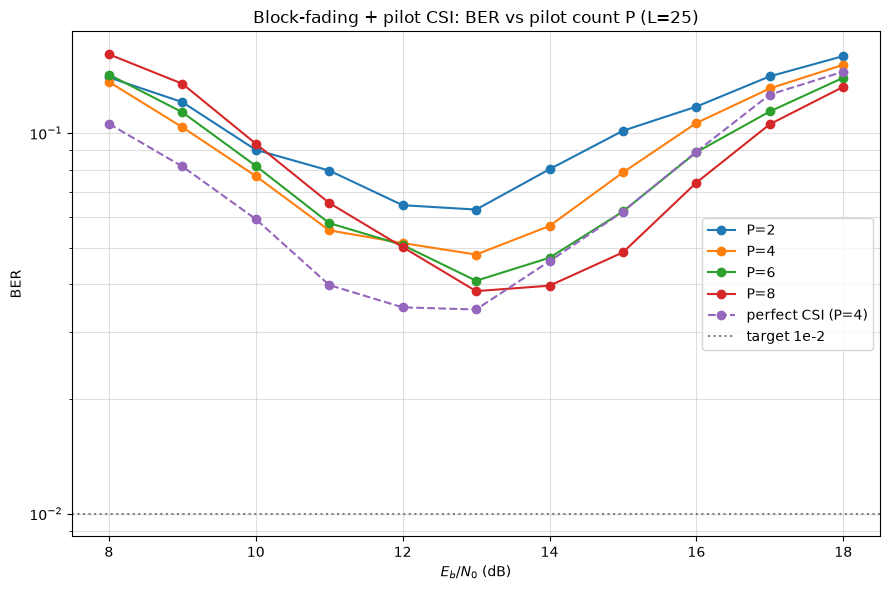

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
for label, ber in BER_pilot.items():
    ber = np.asarray(ber)
    mask = ber > 0
    ls = '--' if 'perfect' in label else '-'
    plt.semilogy(ebno_dbs_pilot[mask], ber[mask], marker='o', linestyle=ls, label=label)
plt.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('Block-fading + pilot CSI: BER vs pilot count P (L=25)')
plt.tight_layout()
plt.savefig('ber_vs_pilot.png', dpi=150)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.1202e-01 | 8.1250e-01 |       32262 |      288000 |          312 |         384 |         1.0 |reached target block errors
      9.0 | 7.5219e-02 | 5.8789e-01 |       28884 |      384000 |          301 |         512 |         1.2 |reached target block errors
     10.0 | 4.1226e-02 | 3.6719e-01 |       27704 |      672000 |          329 |         896 |         2.2 |reached target block errors
     11.0 | 2.0005e-02 | 2.0964e-01 |       23046 |     1152000 |          322 |        1536 |         3.7 |reached target block errors
     12.0 | 6.9781e-03 | 8.0208e-02 |       20097 |     2880000 |          308 |        3840 |         8.9 |reached target block errors
     13.0 | 2.7279e-03 | 3.1456e-02 |       19903 |     7296000 |

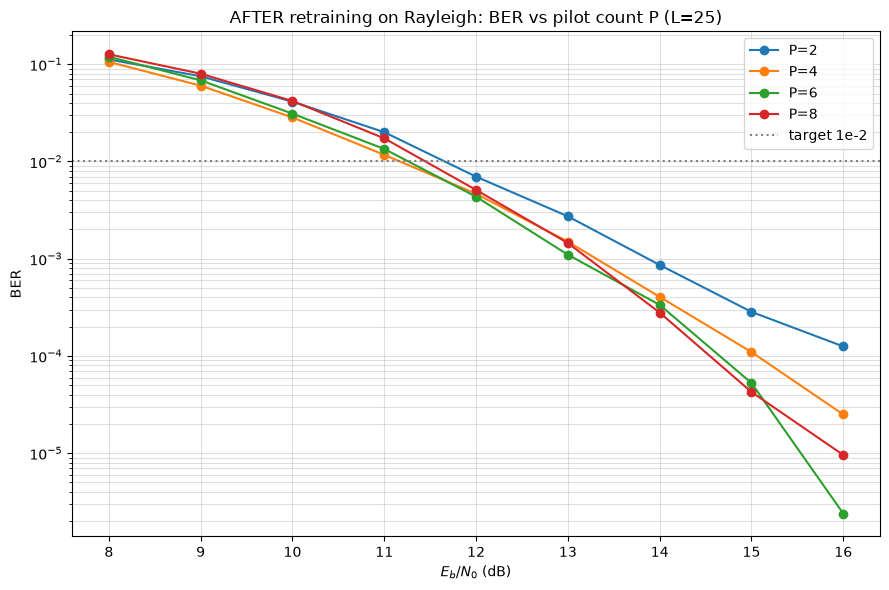

In [37]:
# ============================================================
# 重训后的 P 扫描图（用已存权重，只评估不重训）
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

ebno_dbs_final = np.arange(8.0, 16.1, 1.0)
BER_final = {}

for P in [2, 4, 6, 8]:
    me = E2ESystemPilotCSI(P=P, L=25, training=False, perfect_csi=False).to(device)
    load_weights(me, f'rayleigh_pilot_weights_P{P}')
    with torch.no_grad():
        ber, _ = sim_ber(me, ebno_dbs_final, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)
    BER_final[f'P={P}'] = ber.cpu().numpy()
    print(f'--- P={P} done ---')

# ============ 画图 ============
plt.figure(figsize=(9, 6))
for label, ber in BER_final.items():
    ber = np.asarray(ber)
    mask = ber > 0
    plt.semilogy(ebno_dbs_final[mask], ber[mask], marker='o', label=label)
plt.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('AFTER retraining on Rayleigh: BER vs pilot count P (L=25)')
plt.tight_layout()
plt.savefig('ber_vs_P_retrained.png', dpi=150)
plt.show()

### 10b. Bisection (perfect-CSI neural net vs APP baseline)

In [22]:
import numpy as np
for ebno in [10.0, 14.0, 18.0]:
    m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=True).to(device)
    load_weights(m, model_weights_path_conventional_training)
    with torch.no_grad():
        ber, bler = sim_ber(m, np.array([ebno]), batch_size=256,
                            num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.8687e-02 | 5.1172e-01 |       45072 |      768000 |          524 |        1024 |         3.5 |reached target block errors
ebno=10.0: BER=5.8688e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 4.7069e-02 | 4.5625e-01 |       45186 |      960000 |          584 |        1280 |         4.9 |reached target block errors
ebno=14.0: BER=4.7069e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-----------------------------------------------

In [23]:
for ebno in [10.0, 14.0, 18.0]:
    m = BaselineRayleigh().to(device)
    with torch.no_grad():
        ber, _ = sim_ber(m, np.array([ebno]), batch_size=256,
                        num_target_block_errors=500, max_mc_iter=200)
    print(f"Baseline ebno={ebno}: BER={ber.item():.4e}")

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 5.9896e-07 | 1.1719e-04 |          23 |    38400000 |            6 |       51200 |       222.6 |reached max iterations
Baseline ebno=10.0: BER=5.9896e-07
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 0.0000e+00 | 0.0000e+00 |           0 |    38400000 |            0 |       51200 |       228.5 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 14.0 dB.

Baseline ebno=14.0: BER=0.0000e+00
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | run

## 11. Fix: retrain on the Rayleigh channel

Isolate variables: retrain under perfect CSI first (proves the demapper can be fixed), then under pilot estimation (final form).

### 11a. Retrain under perfect CSI + verify the U-shape is gone

In [24]:
# retrain on block-fading + perfect CSI (no pilots yet, isolate variables)
model_rayleigh = E2ESystemPilotCSI(P=4, L=25, training=True, perfect_csi=True).to(device)
load_weights(model_rayleigh, model_weights_path_conventional_training)  # warm-start from AWGN weights

# retrain (SNR range aligned to the block-fading waterfall)
import torch
optimizer = torch.optim.Adam(model_rayleigh.parameters(), lr=1e-3)
for it in range(3000):
    ebno_db = torch.empty(128, device=device).uniform_(8.0, 16.0)  # align to block-fading waterfall
    optimizer.zero_grad()
    loss = model_rayleigh(128, ebno_db)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_rayleigh.parameters(), 1.0)  # guard against deep-fade gradient explosion
    optimizer.step()
    if it % 500 == 0:
        print(f"it {it}: BCE={loss.item():.4f}")

save_weights(model_rayleigh, 'rayleigh_perfect_csi_weights')

it 0: BCE=0.3672
it 500: BCE=0.2246
it 1000: BCE=0.2076
it 1500: BCE=0.2121
it 2000: BCE=0.2009
it 2500: BCE=0.2070


In [25]:
import numpy as np

print("=== after retrain (rayleigh_perfect_csi_weights) ===")
for ebno in [10.0, 14.0, 18.0]:
    m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=True).to(device)
    load_weights(m, 'rayleigh_perfect_csi_weights')       # <- use new weights
    with torch.no_grad():
        ber, bler = sim_ber(m, np.array([ebno]), batch_size=256,
                            num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

=== after retrain (rayleigh_perfect_csi_weights) ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.4723e-02 | 1.5835e-01 |       36749 |     2496000 |          527 |        3328 |        12.3 |reached target block errors
ebno=10.0: BER=1.4723e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 9.3750e-05 | 1.3477e-03 |        3600 |    38400000 |           69 |       51200 |       230.0 |reached max iterations
ebno=14.0: BER=9.3750e-05
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status

### 11b. Retrain under pilot estimation + verify the target is met (final form)

In [26]:
# final form: block-fading + pilot-estimated CSI, retrain
model_pilot = E2ESystemPilotCSI(P=4, L=25, training=True, perfect_csi=False).to(device)
load_weights(model_pilot, model_weights_path_conventional_training)  # warm-start from AWGN

optimizer = torch.optim.Adam(model_pilot.parameters(), lr=1e-3)
for it in range(3000):
    ebno_db = torch.empty(128, device=device).uniform_(8.0, 16.0)
    optimizer.zero_grad()
    loss = model_pilot(128, ebno_db)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_pilot.parameters(), 1.0)
    optimizer.step()
    if it % 500 == 0:
        print(f"it {it}: BCE={loss.item():.4f}")

save_weights(model_pilot, 'rayleigh_pilot_csi_weights')

it 0: BCE=0.3882
it 500: BCE=0.2431
it 1000: BCE=0.2405
it 1500: BCE=0.2388
it 2000: BCE=0.2284
it 2500: BCE=0.2300


In [27]:
import numpy as np

print("=== pilot estimation + retrain (rayleigh_pilot_csi_weights) ===")
for ebno in [10.0, 14.0, 18.0]:
    m = E2ESystemPilotCSI(P=4, L=25, training=False, perfect_csi=False).to(device)
    load_weights(m, 'rayleigh_pilot_csi_weights')
    with torch.no_grad():
        ber, bler = sim_ber(m, np.array([ebno]), batch_size=256,
                            num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

=== pilot estimation + retrain (rayleigh_pilot_csi_weights) ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 3.0705e-02 | 3.1529e-01 |       41268 |     1344000 |          565 |        1792 |         6.9 |reached target block errors
ebno=10.0: BER=3.0705e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 3.5198e-04 | 5.0391e-03 |       13516 |    38400000 |          258 |       51200 |       283.9 |reached max iterations
ebno=14.0: BER=3.5198e-04
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] 

## 12. Pilot sweep: retrain each P separately, find the optimal pilot count

~20-25 min. Conclusion: the optimal P depends on SNR, with a crossover near 11 dB.

In [28]:
import numpy as np

ebno_dbs_final = np.arange(8.0, 16.1, 1.0)
P_list = [2, 4, 6, 8]
BER_final = {}
weights_by_P = {}

# 1) retrain each P separately (warm-start from AWGN)
for P in P_list:
    print(f"===== retrain P={P} =====")
    mt = E2ESystemPilotCSI(P=P, L=25, training=True, perfect_csi=False).to(device)
    load_weights(mt, model_weights_path_conventional_training)
    opt = torch.optim.Adam(mt.parameters(), lr=1e-3)
    for it in range(2000):
        ebno_db = torch.empty(128, device=device).uniform_(8.0, 16.0)
        opt.zero_grad()
        loss = mt(128, ebno_db)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mt.parameters(), 1.0)
        opt.step()
    wpath = f'rayleigh_pilot_weights_P{P}'
    save_weights(mt, wpath)
    weights_by_P[P] = wpath
    print(f"  P={P} trained, BCE={loss.item():.4f}")

# 2) evaluate BER for each P
for P in P_list:
    me = E2ESystemPilotCSI(P=P, L=25, training=False, perfect_csi=False).to(device)
    load_weights(me, weights_by_P[P])
    with torch.no_grad():
        ber, _ = sim_ber(me, ebno_dbs_final, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)
    BER_final[f'P={P}'] = ber.cpu().numpy()
    print(f"--- P={P} evaluated ---")

===== retrain P=2 =====
  P=2 trained, BCE=0.2163
===== retrain P=4 =====
  P=4 trained, BCE=0.2252
===== retrain P=6 =====
  P=6 trained, BCE=0.2442
===== retrain P=8 =====
  P=8 trained, BCE=0.2447
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.1283e-01 | 8.0469e-01 |       32494 |      288000 |          309 |         384 |         3.2 |reached target block errors
      9.0 | 7.5117e-02 | 6.2500e-01 |       28845 |      384000 |          320 |         512 |         4.1 |reached target block errors
     10.0 | 3.7329e-02 | 3.6719e-01 |       25085 |      672000 |          329 |         896 |         6.9 |reached target block errors
     11.0 | 1.8932e-02 | 1.9727e-01 |       21810 |     1152000 |          303 |        1536 |        11.7 |reached target block errors
 

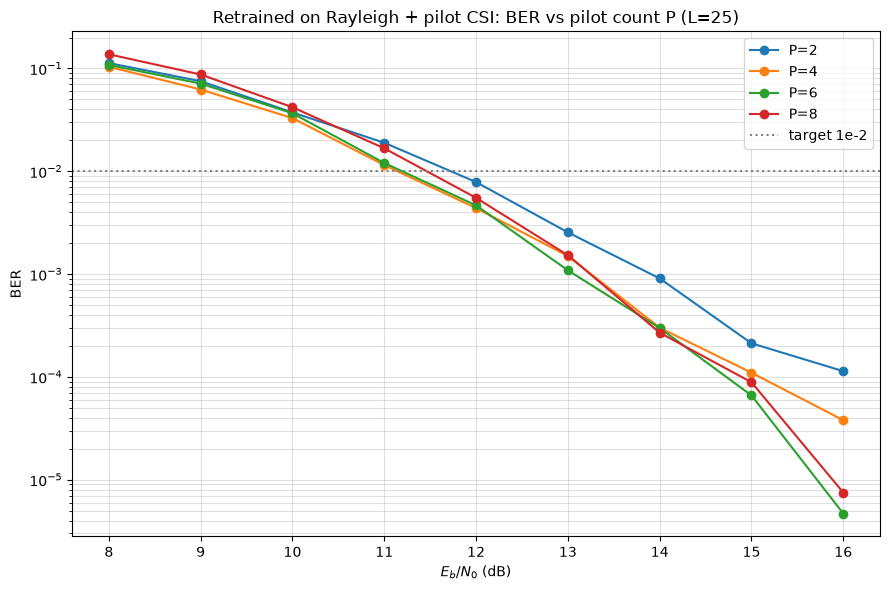

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 6))
for label, ber in BER_final.items():
    ber = np.asarray(ber)
    mask = ber > 0
    plt.semilogy(ebno_dbs_final[mask], ber[mask], marker='o', label=label)
plt.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('Retrained on Rayleigh + pilot CSI: BER vs pilot count P (L=25)')
plt.tight_layout()
plt.savefig('ber_vs_P_retrained.png', dpi=150)
plt.show()

## 13. CNN vs MLP comparison

Conclusion: under flat block-fading, CNN and MLP are essentially on par (MLP slightly better), because after equalization there is no spatial correlation between symbols to exploit.

In [30]:
mc = E2ESystemPilotCNN(P=2, L=25, training=False, perfect_csi=False).to(device)
ebno = torch.tensor(12.0, device=device)
b, b_hat = mc(64, ebno)
print("b:", b.shape, "b_hat:", b_hat.shape)   # expect [64,750] [64,750]
print("forward pass OK")

b: torch.Size([64, 750]) b_hat: torch.Size([64, 750])
forward pass OK


In [31]:
# train CNN demapper (P=2 optimal, from scratch)
model_cnn = E2ESystemPilotCNN(P=2, L=25, training=True, perfect_csi=False).to(device)

optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
for it in range(4000):                      # CNN trains from scratch, give it more steps than MLP
    ebno_db = torch.empty(128, device=device).uniform_(8.0, 16.0)
    optimizer.zero_grad()
    loss = model_cnn(128, ebno_db)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_cnn.parameters(), 1.0)
    optimizer.step()
    if it % 500 == 0:
        print(f"it {it}: BCE={loss.item():.4f}")

save_weights(model_cnn, 'rayleigh_cnn_P2_weights')

it 0: BCE=0.6971
it 500: BCE=0.3081
it 1000: BCE=0.2687
it 1500: BCE=0.2475
it 2000: BCE=0.2430
it 2500: BCE=0.2457
it 3000: BCE=0.2583
it 3500: BCE=0.2428


In [32]:
import numpy as np
print("=== CNN P=2 ===")
for ebno in [10.0, 14.0, 18.0]:
    m = E2ESystemPilotCNN(P=2, L=25, training=False, perfect_csi=False).to(device)
    load_weights(m, 'rayleigh_cnn_P2_weights')
    with torch.no_grad():
        ber, _ = sim_ber(m, np.array([ebno]), batch_size=256,
                         num_target_block_errors=500, max_mc_iter=200)
    print(f"ebno={ebno}: BER={ber.item():.4e}")

=== CNN P=2 ===
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.1871e-02 | 3.8932e-01 |       48235 |     1152000 |          598 |        1536 |         5.8 |reached target block errors
ebno=10.0: BER=4.1871e-02
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     14.0 | 8.6258e-04 | 1.1626e-02 |       27989 |    32448000 |          503 |       43264 |       202.0 |reached target block errors
ebno=14.0: BER=8.6258e-04
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
-------------------------------

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      8.0 | 1.1282e-01 | 8.0469e-01 |       32492 |      288000 |          309 |         384 |         1.5 |reached target block errors
      9.0 | 7.5875e-02 | 5.9570e-01 |       29136 |      384000 |          305 |         512 |         1.9 |reached target block errors
     10.0 | 3.8144e-02 | 3.5491e-01 |       25633 |      672000 |          318 |         896 |         3.3 |reached target block errors
     11.0 | 1.7964e-02 | 1.7913e-01 |       24143 |     1344000 |          321 |        1792 |         6.7 |reached target block errors
     12.0 | 7.1997e-03 | 8.0208e-02 |       20735 |     2880000 |          308 |        3840 |        14.0 |reached target block errors
     13.0 | 2.6632e-03 | 3.1771e-02 |       19175 |     7200000 |

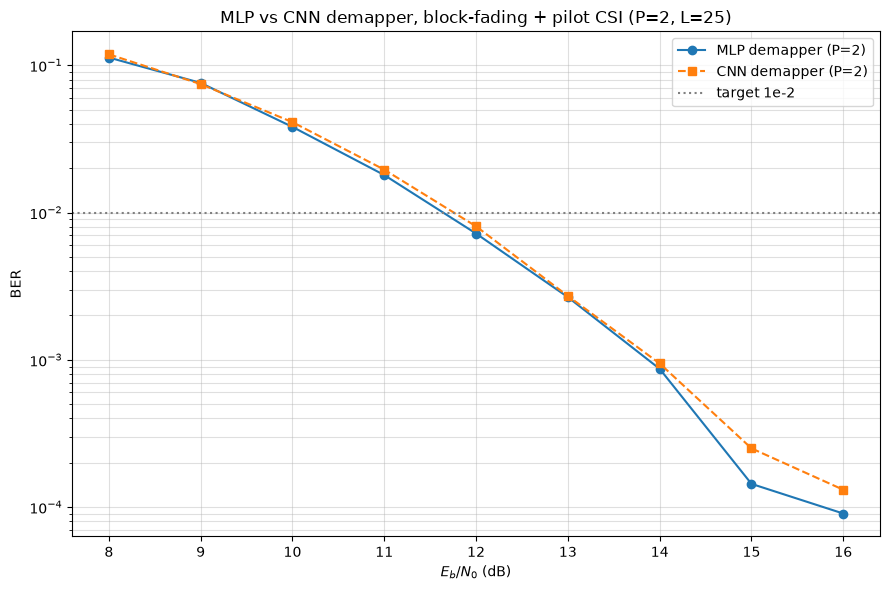

In [33]:
import numpy as np
import matplotlib.pyplot as plt

ebno_cmp = np.arange(8.0, 16.1, 1.0)

# MLP (P=2) -- use the previously saved weights
m_mlp = E2ESystemPilotCSI(P=2, L=25, training=False, perfect_csi=False).to(device)
load_weights(m_mlp, weights_by_P[2])          # P=2 weights saved during the pilot sweep
with torch.no_grad():
    ber_mlp, _ = sim_ber(m_mlp, ebno_cmp, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)

# CNN (P=2)
m_cnn = E2ESystemPilotCNN(P=2, L=25, training=False, perfect_csi=False).to(device)
load_weights(m_cnn, 'rayleigh_cnn_P2_weights')
with torch.no_grad():
    ber_cnn, _ = sim_ber(m_cnn, ebno_cmp, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)

ber_mlp = ber_mlp.cpu().numpy()
ber_cnn = ber_cnn.cpu().numpy()

plt.figure(figsize=(9, 6))
mask = ber_mlp > 0
plt.semilogy(ebno_cmp[mask], ber_mlp[mask], 'o-', label='MLP demapper (P=2)')
mask = ber_cnn > 0
plt.semilogy(ebno_cmp[mask], ber_cnn[mask], 's--', label='CNN demapper (P=2)')
plt.axhline(1e-2, color='gray', ls=':', label='target 1e-2')
plt.xlabel(r'$E_b/N_0$ (dB)')
plt.ylabel('BER')
plt.grid(which='both', alpha=0.4)
plt.legend()
plt.title('MLP vs CNN demapper, block-fading + pilot CSI (P=2, L=25)')
plt.tight_layout()
plt.savefig('ber_mlp_vs_cnn.png', dpi=150)
plt.show()

In [34]:
# ============================================================
# Width sweep: is 128 hidden units overkill?
# Train the SAME task (AWGN) at width 16/32/64/128, then
# compare converged BCE and BER at a few SNR points.
# ============================================================
import numpy as np
import copy

widths = [16, 32, 64, 128]
sweep_iters = 5000          # 一半于原版10000，足够看收敛趋势且省时
eval_ebno = np.array([5.0, 6.0, 7.0])   # AWGN 瀑布区三点
results = {}

for w in widths:
    print(f"===== width={w} =====")
    torch.manual_seed(42)                      # ← 同一初始化种子，公平对比
    model = E2ESystemConventionalTraining(training=True).to(device)
    # 换上指定宽度的 demapper（星座参数保持原版初始化）
    model._demapper = NeuralDemapper(width=w).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for it in range(sweep_iters):
        ebno_db = torch.empty(128, device=device).uniform_(ebno_db_min, ebno_db_max)
        opt.zero_grad()
        loss = model(128, ebno_db)
        loss.backward()
        opt.step()
    final_bce = loss.item()

    # 参数量统计（只算 demapper）
    n_params = sum(p.numel() for p in model._demapper.parameters())

    # 评估 BER
    wpath = f'awgn_width{w}_weights'
    save_weights(model, wpath)
    me = E2ESystemConventionalTraining(training=False).to(device)
    me._demapper = NeuralDemapper(width=w).to(device)
    load_weights(me, wpath)
    with torch.no_grad():
        ber, _ = sim_ber(me, eval_ebno, batch_size=128,
                         num_target_block_errors=300, max_mc_iter=100)
    results[w] = {'bce': final_bce, 'params': n_params,
                  'ber': ber.cpu().numpy()}
    print(f"  width={w}: params={n_params}, BCE={final_bce:.4f}")

# ============ 汇总表 ============
print("\n================= SUMMARY =================")
print(f"{'width':>6} | {'params':>7} | {'BCE':>7} | {'BER@5dB':>10} | {'BER@6dB':>10} | {'BER@7dB':>10}")
for w in widths:
    r = results[w]
    print(f"{w:>6} | {r['params']:>7} | {r['bce']:.4f} | "
          f"{r['ber'][0]:.3e} | {r['ber'][1]:.3e} | {r['ber'][2]:.3e}")

===== width=16 =====
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      5.0 | 5.4396e-02 | 8.0990e-01 |       15666 |      288000 |          311 |         384 |         0.8 |reached target block errors
      6.0 | 1.6155e-03 | 5.2480e-02 |        7134 |     4416000 |          309 |        5888 |        11.6 |reached target block errors
      7.0 | 5.2083e-07 | 2.3437e-04 |           5 |     9600000 |            3 |       12800 |        26.0 |reached max iterations
  width=16: params=438, BCE=0.3000
===== width=32 =====
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      5.0 

In [36]:
import os
for P in [2, 4, 6, 8]:
    f = f'rayleigh_pilot_weights_P{P}'
    print(f, '→', '存在 ✓' if os.path.exists(f) else '不存在 ✗')

rayleigh_pilot_weights_P2 → 存在 ✓
rayleigh_pilot_weights_P4 → 存在 ✓
rayleigh_pilot_weights_P6 → 存在 ✓
rayleigh_pilot_weights_P8 → 存在 ✓
